
---

# 🧩 ***`Principal Component Analysis (PCA) in Machine Learning for Data Science`*** 🚀  

### **📌 PCA is a powerful technique used for:**  
✅ **Dimensionality reduction** → Reduce large feature sets into fewer components.  
✅ **Feature extraction** → Creates new uncorrelated features (principal components).  
✅ **Improving model performance** → Speeds up training and reduces overfitting.  
✅ **Visualization** → Allows plotting high-dimensional data in **2D or 3D**.  

---

## 🎯 **1. Covariance and Covariance Matrix**  

### **What is Covariance?**  
Covariance measures how **two variables change together**.  

- **Positive Covariance** → When **one increases, the other also increases**.  
- **Negative Covariance** → When **one increases, the other decreases**.  
- **Zero Covariance** → **No relationship** between variables.  

**Formula:**  
$$
\text{Cov}(X, Y) = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{n-1}
$$

### **Covariance Matrix**  
For **multiple features**, we calculate the **covariance between each pair of features**, resulting in a **Covariance Matrix**.

📌 **Example:**

In [9]:
import numpy as np
import pandas as pd

# Sample Data (2 features)
X = np.array([[2, 3], [3, 6], [4, 8], [5, 10]])

# Compute Covariance Matrix
cov_matrix = np.cov(X.T)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.66666667 3.83333333]
 [3.83333333 8.91666667]]


📌 **Interpretation:**  
- **Diagonal values** (e.g., `1.67` and `6.67`) → Variance of each feature.  
- **Off-diagonal values** (e.g., `3.33`) → Covariance between features.  

💡 **PCA finds new axes (principal components) by identifying directions of maximum covariance.**

---

## 🎯 **2. Eigenvalues and Eigenvectors**  

### **What are Eigenvalues and Eigenvectors?**  
- **Eigenvectors** → Define the **directions of principal components**.  
- **Eigenvalues** → Indicate the **amount of variance** captured by each eigenvector.  

📌 **Mathematically, PCA solves:**  
$$
Cov(X) v = \lambda v
$$

Where:  
- $v$ = **Eigenvector (Principal Component direction)**  
- $\lambda $ = **Eigenvalue (Amount of variance explained)**  

---

### 🔢 **Computing Eigenvalues and Eigenvectors in Python**

In [10]:
# Compute Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [ 0.01577153 10.5675618 ]

Eigenvectors:
 [[-0.9184463 -0.3955457]
 [ 0.3955457 -0.9184463]]



📌 **Interpretation:**  
- **Eigenvectors** → Define the **axes of maximum variance**.  
- **Eigenvalues** → Indicate **variance captured** by each eigenvector.  

💡 **PCA selects top eigenvectors to transform data into a new space.**  

---

## 🎯 **3. Visualizing Linear Transformations**  

PCA **rotates data** into a new coordinate system **aligned with principal components**.

📌 **Example:**

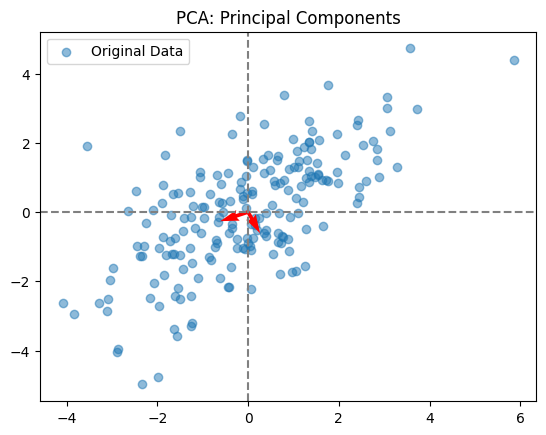

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Data
np.random.seed(42)
X = np.random.multivariate_normal(mean=[0, 0], cov=[[3, 2], [2, 3]], size=200)

# Scatter Plot
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Original Data")

# Plot Eigenvectors (Principal Components)
for eigenvector, eigenvalue in zip(eigenvectors, eigenvalues):
    plt.quiver(0, 0, eigenvector[0], eigenvector[1], angles='xy', scale_units='xy', scale=1.5, color='r')

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.legend()
plt.title("PCA: Principal Components")
plt.show()

📌 **Interpretation:**  
- **Scatterplot** shows the **original data**.  
- **Red arrows** show the **principal component directions** (eigenvectors).  

💡 **PCA transforms data by aligning it along these new axes.**

---

## 🎯 **4. Eigendecomposition of the Covariance Matrix**  

📌 **Steps to Compute PCA:**  
1️⃣ **Compute Covariance Matrix**  
2️⃣ **Perform Eigendecomposition** → Compute Eigenvalues & Eigenvectors  
3️⃣ **Sort Eigenvalues** in descending order  
4️⃣ **Select top K components**  
5️⃣ **Transform data using Eigenvectors**

📌 **Step-by-Step Python Implementation**

In [12]:
# Sort eigenvalues & eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Select top K (here, K=1 for 1D projection)
K = 1
top_eigenvectors = eigenvectors[:, :K]

# Transform Data
X_pca = X.dot(top_eigenvectors)

print("\nReduced Data (1D Projection):\n", X_pca[:5])


Reduced Data (1D Projection):
 [[ 1.08309795]
 [ 0.7825051 ]
 [-0.3999066 ]
 [ 2.99722215]
 [-1.17599146]]



📌 **Interpretation:**  
- **Data is projected** onto the first principal component.  
- **Reduces dimensionality while preserving variance.**  

---

## 🎯 **5. How to Solve PCA? (Full Implementation in Sklearn)**  

📌 **Example: Reducing `Iris Dataset` from 4D to 2D**

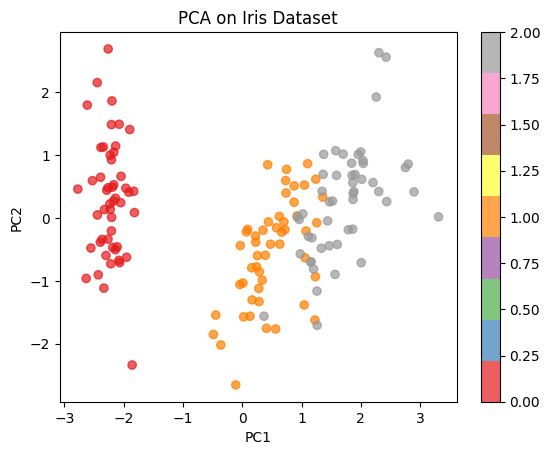

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

# Load Iris Dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatter Plot of PCA-Reduced Data
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA on Iris Dataset")
plt.colorbar()
plt.show()

📌 **Observations:**  
- PCA **reduces 4D data to 2D** while preserving class separability.  
- **Improves visualization & speeds up model training.**  

---

## 🎯 **6. How to Transform New Points Using PCA?**  

Once trained, PCA can transform **new data points** using the **same principal components**.

📌 **Transforming New Data**

In [14]:
new_point = np.array([[5.5, 3.2, 1.8, 0.2]])  # A new flower measurement
new_point_scaled = scaler.transform(new_point)  # Standardize
new_point_pca = pca.transform(new_point_scaled)  # Apply PCA

print("\nNew Data Transformed to PCA Space:", new_point_pca)


New Data Transformed to PCA Space: [[-1.69419154  0.03089929]]


📌 **Effect:**  
- Converts **new 4D point → 2D PCA space**.  
- Ensures **new data is compatible with trained ML models**.  

---

## 🏆 **7. Key Takeaways**  

✔ **PCA finds principal components (new axes) to reduce dimensionality.**  
✔ **Eigenvalues show variance captured, Eigenvectors define new feature space.**  
✔ **PCA requires standardization** (mean=0, variance=1) for optimal performance.  
✔ **Visualization helps understand PCA transformations.**  
✔ **Use PCA for high-dimensional datasets to improve ML efficiency.**  

💡 **Pro Tip:** Always check the **Explained Variance Ratio** to determine the **optimal number of components**.

---